# Credit Card Fraud Detection - Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the Credit Card Fraud Detection dataset, understand its characteristics, identify class imbalance, analyze feature distributions, and generate insights that will help build effective machine learning models.

---

### Dataset Information

- Source: Kaggle Credit Card Fraud Detection Dataset
- Transactions: 284,807
- Features: 30 numerical features (V1–V28, Time, Amount)
- Target Variable:
  - 0 → Legitimate Transaction
  - 1 → Fraudulent Transaction

Credit Card Fraud Detection
===========================

1. Import Libraries

2. Load Dataset

3. Dataset Overview

4. Data Quality Check

5. Exploratory Data Analysis

6. Summary of Insights

1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


plt.style.use("ggplot")


pd.set_option("display.max_columns", None)


os.makedirs("../images", exist_ok=True)

2. Load Dataset

In [2]:
df = pd.read_csv("../data/creditcard.csv")

print("Dataset Loaded Successfully!")

df.head()

Dataset Loaded Successfully!


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


3. Dataset Shape

In [3]:
print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Rows : 284807
Columns : 31


4. Dataset Information

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

5. Statistical Summary

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.175161e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.384974e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.094852e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,1.021879e-15,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.494498e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.620335e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.149614e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.414189e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


6. Missing Values

In [6]:
missing_values = df.isnull().sum()

missing_values

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

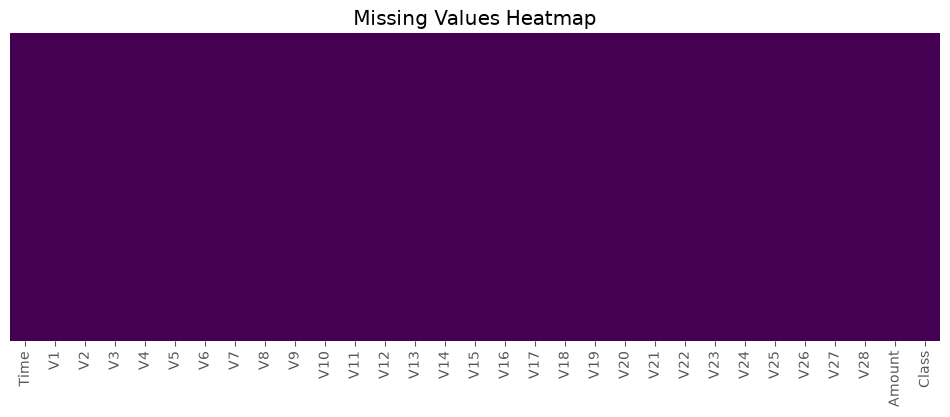

In [7]:
plt.figure(figsize=(12,4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")

plt.savefig("../images/missing_values.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

7. Duplicate Records

In [8]:
duplicates = df.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 1081


8. Class Distribution

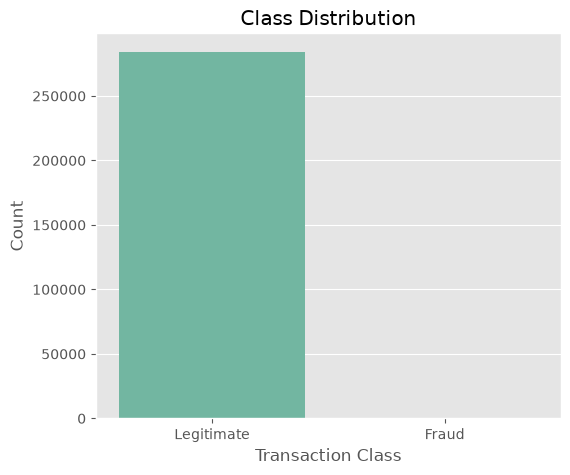

In [9]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    x="Class",
    data=df,
    palette="Set2"
)

plt.title("Class Distribution")

plt.xlabel("Transaction Class")

plt.ylabel("Count")

ax.set_xticklabels(["Legitimate", "Fraud"])

plt.savefig("../images/class_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

9. Class Percentage

In [10]:
fraud_percentage = (df["Class"].value_counts(normalize=True) * 100)

fraud_percentage

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

### Observation

The dataset is **highly imbalanced**.

- Legitimate transactions represent approximately **99.83%** of the data.
- Fraudulent transactions represent only **0.17%**.

This imbalance makes accuracy an unreliable evaluation metric. Therefore, precision, recall, F1-score, ROC-AUC, and Precision-Recall curves will be emphasized during model evaluation.

10. Transaction Amount Distribution

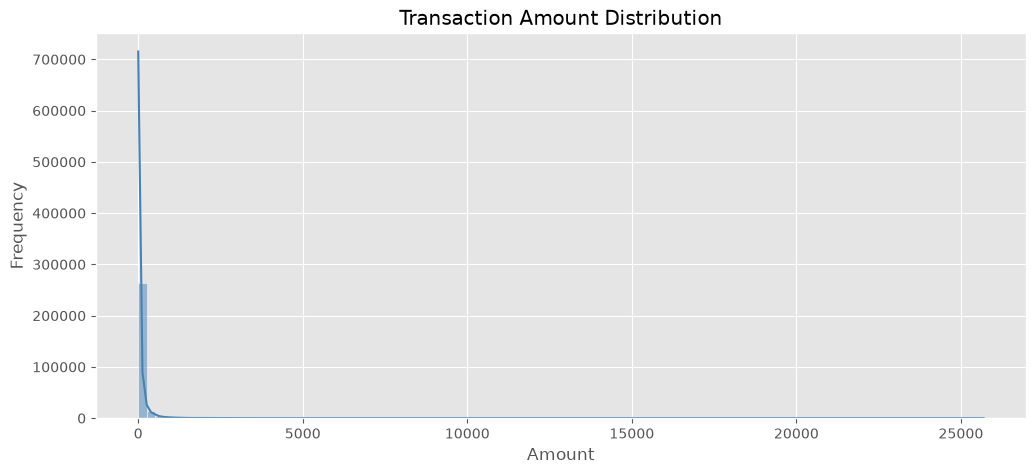

In [23]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["Amount"],
    bins=100,
    kde=True,
    color="steelblue"
)

plt.title("Transaction Amount Distribution")

plt.xlabel("Amount")

plt.ylabel("Frequency")

plt.savefig("../images/amount_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

11. Transaction Time Distribution

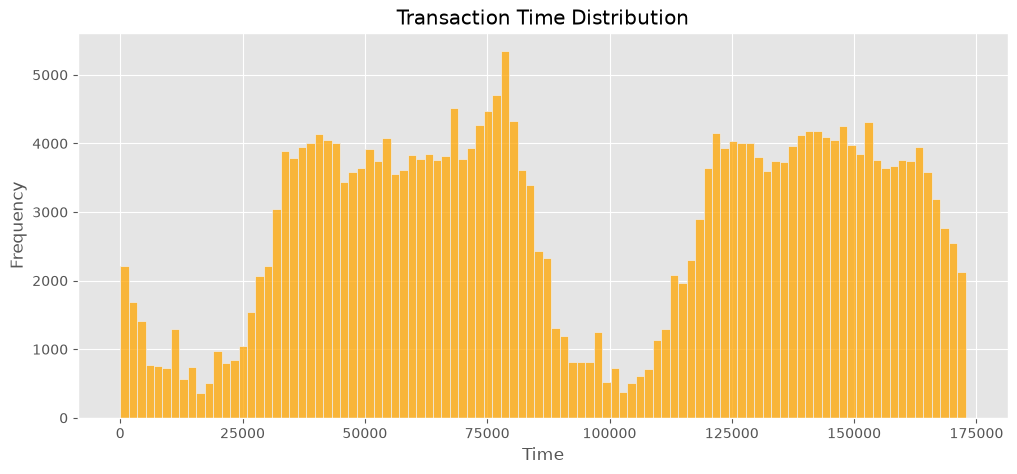

In [24]:
plt.figure(figsize=(12,5))

sns.histplot(
    df["Time"],
    bins=100,
    color="orange"
)

plt.title("Transaction Time Distribution")

plt.xlabel("Time")

plt.ylabel("Frequency")

plt.savefig("../images/time_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

12. Class Count Table

In [25]:
# Class count
class_counts = df["Class"].value_counts()

print(class_counts)

# Percentage
class_percentage = df["Class"].value_counts(normalize=True) * 100

print("\nPercentage\n")
print(class_percentage)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


## Observation

The dataset is extremely imbalanced.

| Class | Meaning | Percentage |
|-------|---------|------------|
| 0 | Legitimate | ~99.83% |
| 1 | Fraud | ~0.17% |

This imbalance requires special handling during model training. Accuracy alone will not be an appropriate evaluation metric.

13. Transaction Amount by Class

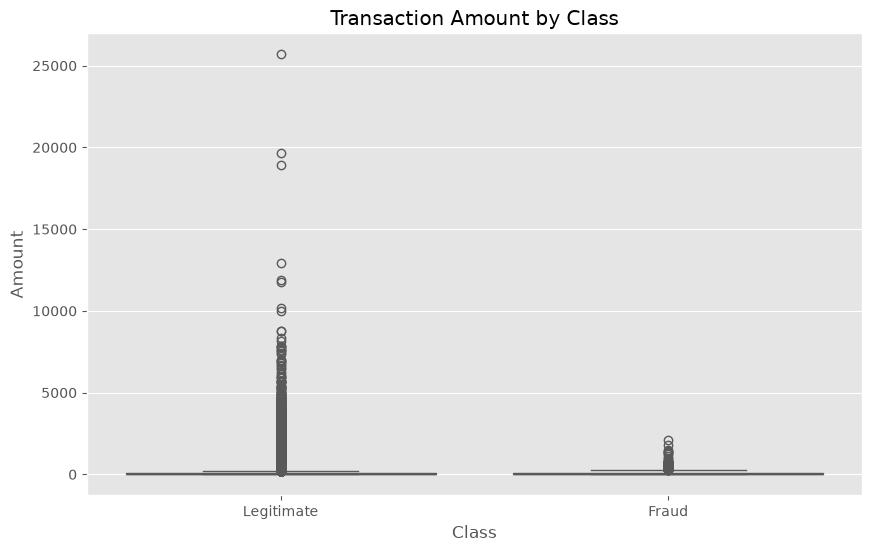

In [14]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df,
    palette="Set2"
)

plt.xticks([0,1],["Legitimate","Fraud"])

plt.title("Transaction Amount by Class")

plt.savefig("../images/amount_boxplot.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

Fraudulent transactions occur across a wide range of transaction amounts.

Although most fraudulent transactions involve relatively smaller amounts, some high-value frauds are also present.

14. Log Distribution of Amount

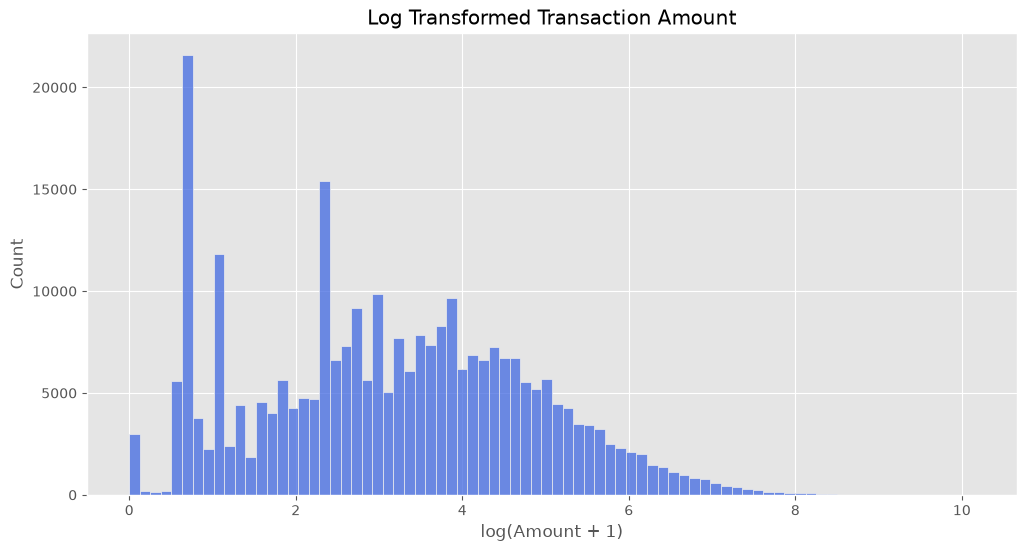

In [15]:
plt.figure(figsize=(12,6))

sns.histplot(
    np.log1p(df["Amount"]),
    bins=80,
    color="royalblue"
)

plt.title("Log Transformed Transaction Amount")

plt.xlabel("log(Amount + 1)")

plt.savefig("../images/log_amount_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

15. Correlation Heatmap

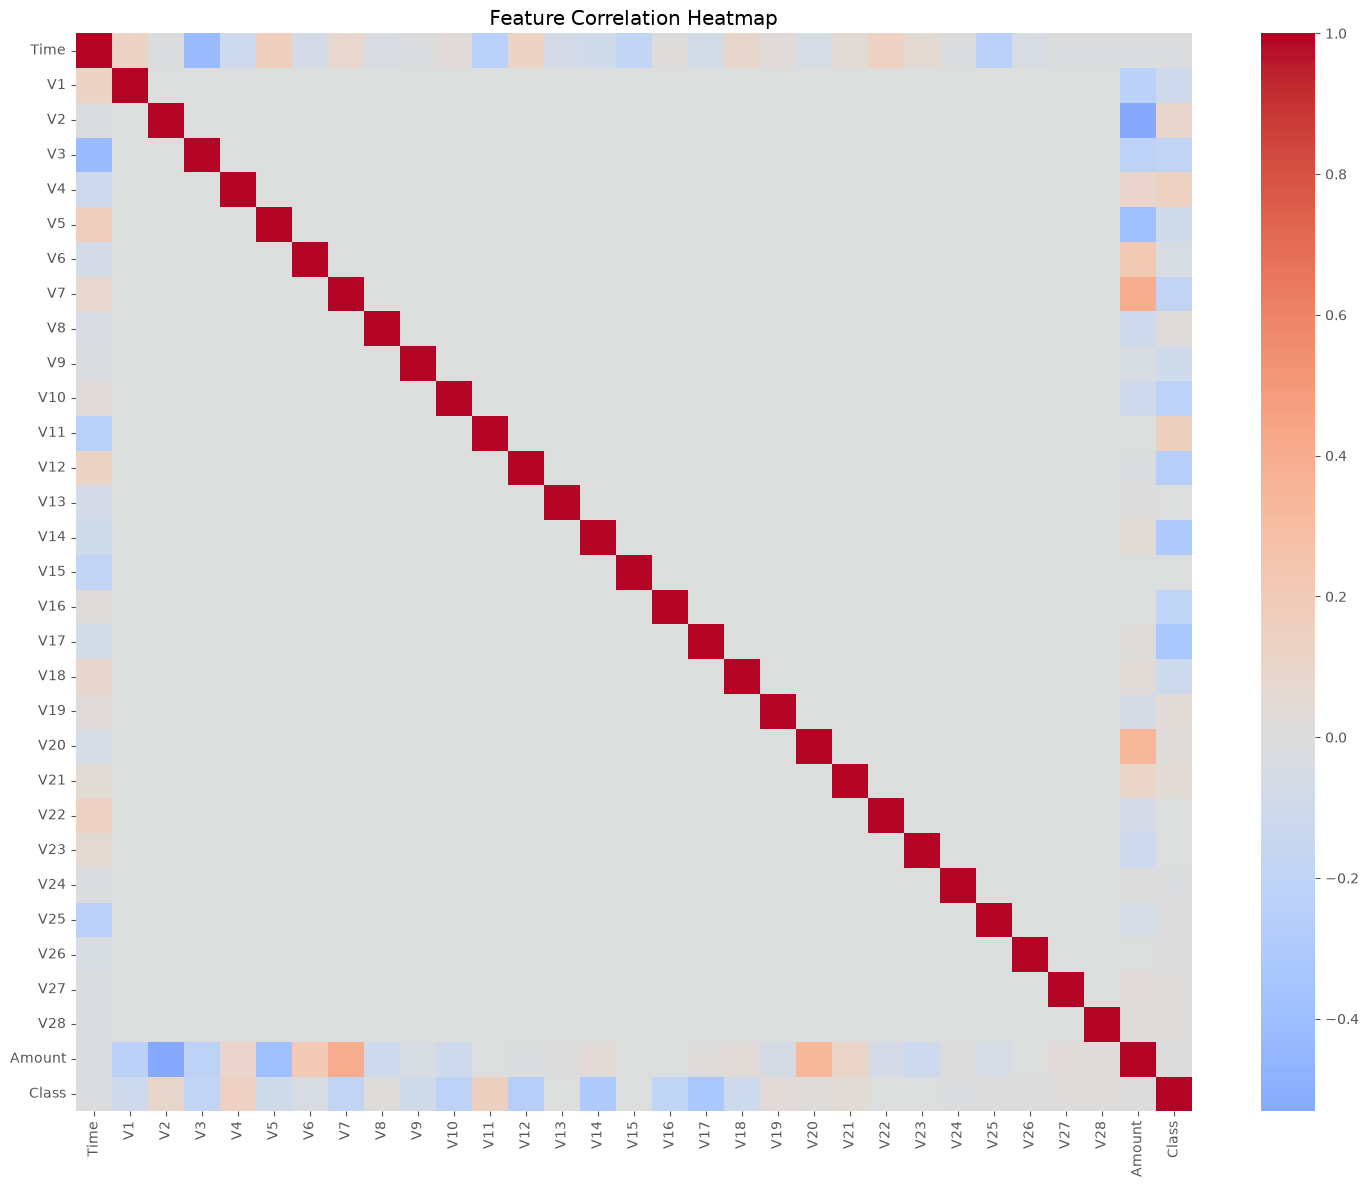

In [16]:
plt.figure(figsize=(18,14))

corr = df.corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.savefig("../images/correlation_heatmap.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Observation

Most PCA-transformed variables exhibit relatively low pairwise correlation, indicating reduced multicollinearity. This is expected because the original dataset was transformed using Principal Component Analysis (PCA).

16. Fraud vs Legitimate Time Distribution

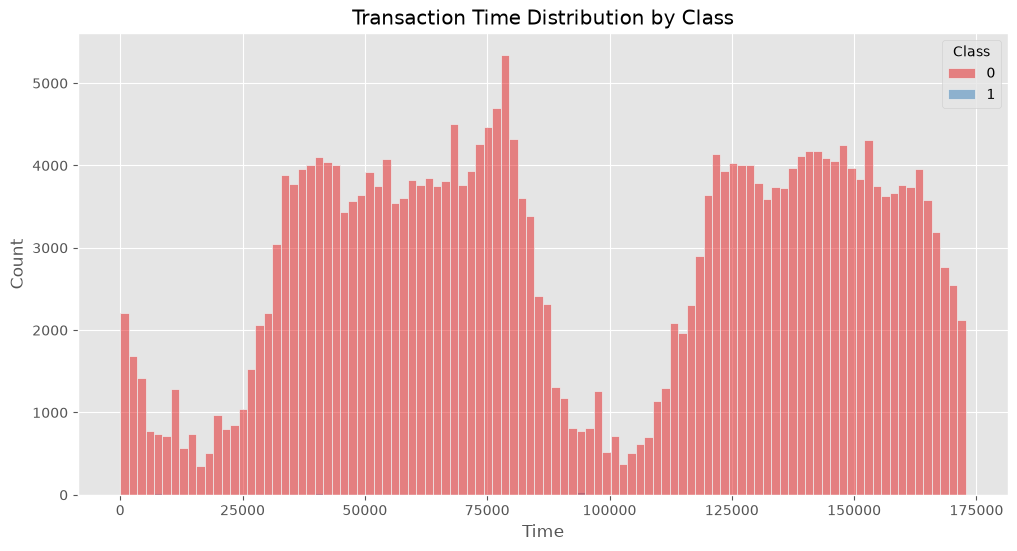

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Time",
    hue="Class",
    bins=100,
    palette="Set1"
)

plt.title("Transaction Time Distribution by Class")

plt.savefig("../images/time_class_distribution.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

17. Top Correlated Features

In [18]:
corr = df.corr()["Class"].sort_values()

corr

V17      -0.326481
V14      -0.302544
V12      -0.260593
V10      -0.216883
V16      -0.196539
V3       -0.192961
V7       -0.187257
V18      -0.111485
V1       -0.101347
V9       -0.097733
V5       -0.094974
V6       -0.043643
Time     -0.012323
V24      -0.007221
V13      -0.004570
V15      -0.004223
V23      -0.002685
V22       0.000805
V25       0.003308
V26       0.004455
Amount    0.005632
V28       0.009536
V27       0.017580
V8        0.019875
V20       0.020090
V19       0.034783
V21       0.040413
V2        0.091289
V4        0.133447
V11       0.154876
Class     1.000000
Name: Class, dtype: float64

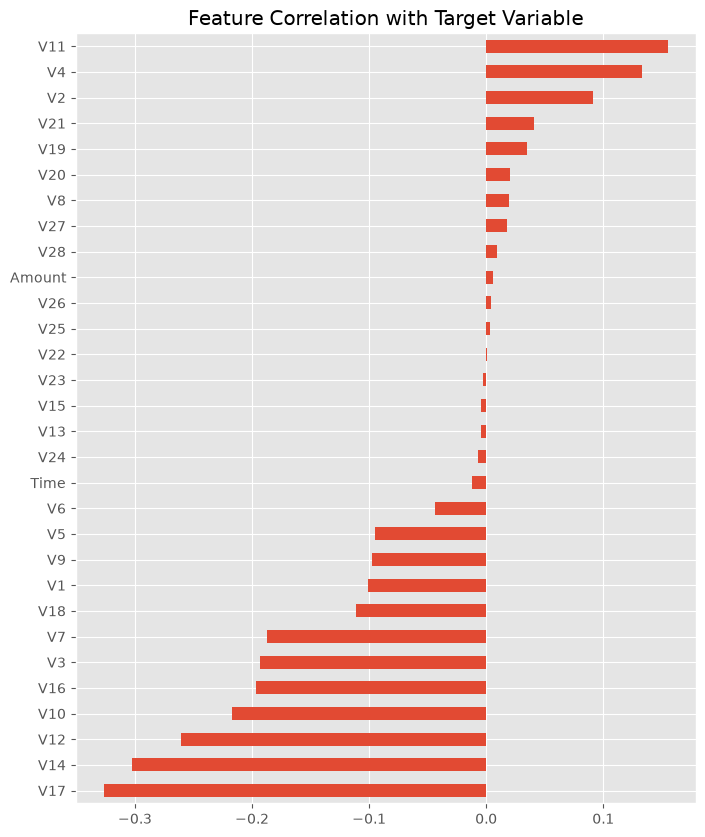

In [19]:
plt.figure(figsize=(8,10))

corr.drop("Class").sort_values().plot(kind="barh")

plt.title("Feature Correlation with Target Variable")

plt.savefig("../images/feature_correlation.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

### Insight

Several PCA features exhibit stronger positive or negative correlations with the target class, making them valuable predictors for fraud detection.

18. Pairplot (Sample Only)

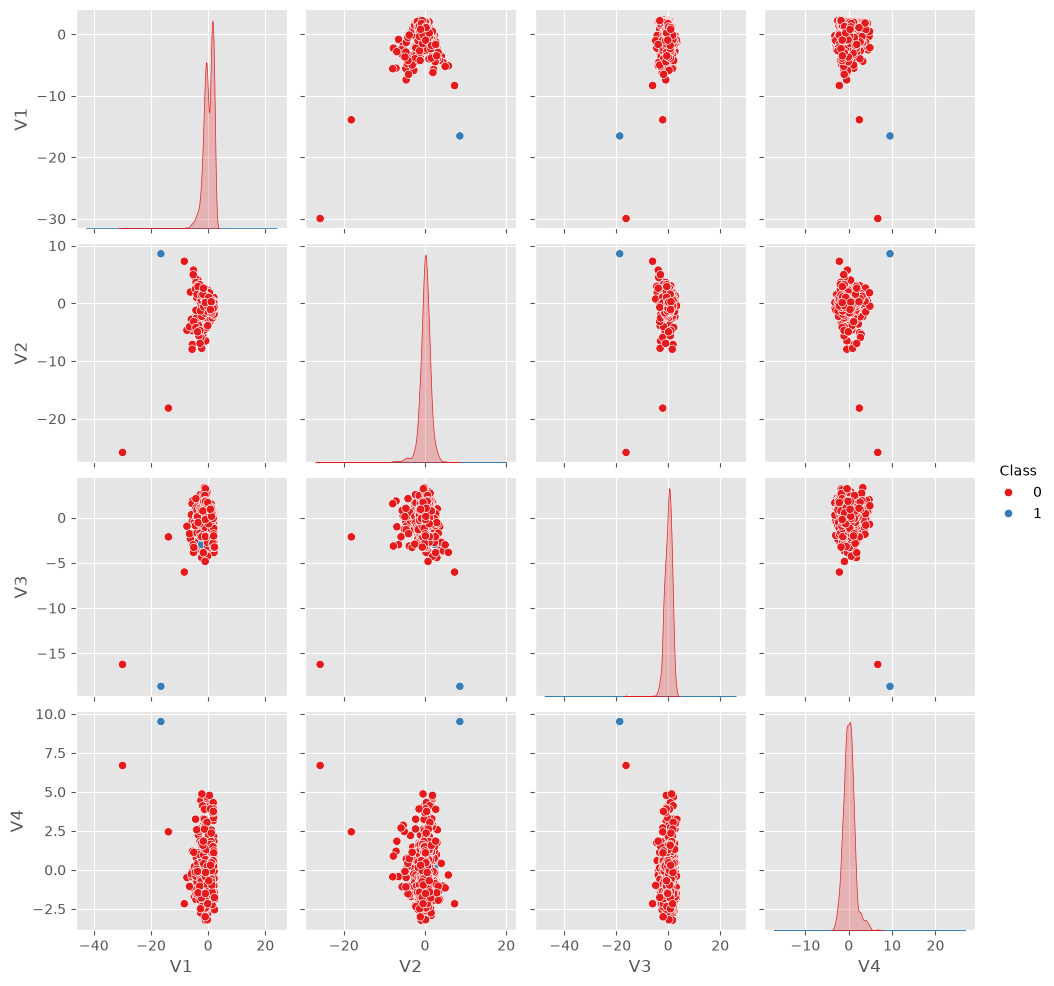

In [20]:
sample = df.sample(1000, random_state=42)

sns.pairplot(
    sample,
    vars=["V1","V2","V3","V4"],
    hue="Class",
    palette="Set1"
)

plt.savefig("../images/pairplot.png",
            dpi=300)

plt.show()

19. Summary Statistics

In [21]:
summary = df.groupby("Class")["Amount"].describe()

summary

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


20. Save Summary Report

In [22]:
summary.to_csv("../reports/eda_summary.csv")

# Exploratory Data Analysis Summary

### Key Findings

- Dataset contains **284,807 transactions**.
- No missing values were detected.
- The dataset is **highly imbalanced**, with fraud cases representing only **0.17%** of all transactions.
- Transaction amounts exhibit a highly skewed distribution.
- PCA-transformed features reduce redundancy and preserve privacy.
- Several features demonstrate meaningful correlation with fraudulent transactions.
- These findings indicate that class imbalance handling and careful model evaluation will be essential during model development.